# Trip Itinerary Planning using Heuristic Optimization

## 1. Introduction

This notebook presents a comparative study of three heuristic optimization algorithms for solving the trip itinerary planning problem:

1. **Simulated Annealing (SA)**
2. **Genetic Algorithm (GA)**
3. **Ant Colony Optimization (ACO)**

The objective is to construct an optimal travel itinerary for tourists visiting a new city. The itinerary should balance three main factors:

- The quality of the selected attractions, represented by their average rating.
- The proximity of attractions, represented by the total commute time.
- The utilization of the available day duration, where the maximum allowed time is 480 minutes.

The objective function is defined as:

\[
f(x) = \frac{1}{1 + \frac{z_c}{480}} \times z_r \times \frac{z_d}{480}
\]

where:

\[
X = [z_d, z_c, z_r]^T
\]

- \(z_d\): total duration of selected attractions.
- \(z_c\): total commute time between selected attractions.
- \(z_r\): average rating of selected attractions.

The itinerary is subject to the following constraints:

\[
z_d + z_c \leq 480
\]

and no venue can be repeated in the same itinerary.

The goal of this notebook is not only to find a high-quality itinerary, but also to compare the algorithms using statistical, computational, convergence, scalability, sensitivity, and ablation analyses.

In [7]:
#Dataset
%pip install numpy pandas matplotlib scipy optalgotools -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
from itertools import permutations
from scipy.stats import ranksums, friedmanchisquare

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
MAX_DAY_TIME = 480

commute_matrix = np.array([
    [0, 10, 20, 7, 11, 8, 19, 7, 1, 1],
    [10, 0, 12, 14, 1, 7, 12, 10, 22, 22],
    [20, 12, 0, 25, 21, 28, 1, 22, 12, 12],
    [7, 14, 25, 0, 15, 15, 25, 4, 6, 6],
    [11, 1, 21, 15, 0, 25, 22, 11, 10, 10],
    [8, 7, 28, 15, 25, 0, 28, 14, 28, 29],
    [19, 12, 1, 25, 22, 28, 0, 22, 12, 12],
    [7, 10, 22, 4, 11, 14, 22, 0, 3, 2],
    [1, 22, 12, 6, 10, 28, 12, 3, 0, 1],
    [1, 22, 12, 6, 10, 29, 12, 2, 1, 0]
])

attractions = pd.DataFrame({
    "ID": np.arange(10),
    "Name": [
        "Starting hotel",
        "Attraction 1",
        "Attraction 2",
        "Attraction 3",
        "Attraction 4",
        "Attraction 5",
        "Attraction 6",
        "Attraction 7",
        "Attraction 8",
        "Attraction 9"
    ],
    "Rating": [0, 2, 3, 3, 0, 5, 1, 4, 0, 2],
    "Duration": [0, 120, 60, 180, 180, 120, 60, 60, 60, 120]
})

display(attractions)

print("Commute matrix shape:", commute_matrix.shape)
print("Maximum allowed itinerary time:", MAX_DAY_TIME, "minutes")

Note: you may need to restart the kernel to use updated packages.


,ID,Name,Rating,Duration
0,0,Starting hotel,0,0
1,1,Attraction 1,2,120
2,2,Attraction 2,3,60
3,3,Attraction 3,3,180
4,4,Attraction 4,0,180
5,5,Attraction 5,5,120
6,6,Attraction 6,1,60
7,7,Attraction 7,4,60
8,8,Attraction 8,0,60
9,9,Attraction 9,2,120


Commute matrix shape: (10, 10)
Maximum allowed itinerary time: 480 minutes


## 2. Solution Representation and Evaluation Functions

An itinerary is represented as an ordered list of attraction IDs.

For example:

\[
[5, 7, 2, 1]
\]

means that the tourist starts from the hotel, visits attraction 5, then attraction 7, then attraction 2, then attraction 1.

The hotel is not included inside the itinerary sequence because it is always assumed to be the starting point. The total commute time is computed from:

\[
0 \rightarrow first\ attraction \rightarrow ... \rightarrow last\ attraction
\]

The following helper functions are used throughout the notebook:

- `calculate_duration`: computes \(z_d\)
- `calculate_commute`: computes \(z_c\)
- `calculate_average_rating`: computes \(z_r\)
- `is_feasible`: checks the time and repetition constraints
- `fitness`: computes the objective value
- `summarize_itinerary`: returns a readable summary of a solution

These functions are shared by all algorithms to ensure a fair comparison.

In [12]:
#Solution evaluation helper functions

def calculate_duration(itinerary, attractions_df=attractions):
    return int(attractions_df.loc[attractions_df["ID"].isin(itinerary), "Duration"].sum())


def calculate_commute(itinerary, commute=commute_matrix):
    if len(itinerary) == 0:
        return 0

    total_commute = commute[0, itinerary[0]]

    for i in range(len(itinerary) - 1):
        total_commute += commute[itinerary[i], itinerary[i + 1]]

    return int(total_commute)


def calculate_average_rating(itinerary, attractions_df=attractions):
    if len(itinerary) == 0:
        return 0.0

    ratings = attractions_df.loc[attractions_df["ID"].isin(itinerary), "Rating"]
    return float(ratings.mean())


def is_feasible(itinerary, max_time=MAX_DAY_TIME):
    if len(itinerary) != len(set(itinerary)):
        return False

    if any(place == 0 for place in itinerary):
        return False

    total_time = calculate_duration(itinerary) + calculate_commute(itinerary)

    return total_time <= max_time


def fitness(itinerary, max_time=MAX_DAY_TIME):
    if not is_feasible(itinerary, max_time=max_time):
        return 0.0

    z_d = calculate_duration(itinerary)
    z_c = calculate_commute(itinerary)
    z_r = calculate_average_rating(itinerary)

    return (1 / (1 + z_c / max_time)) * z_r * (z_d / max_time)


def summarize_itinerary(itinerary):

    z_d = calculate_duration(itinerary)
    z_c = calculate_commute(itinerary)
    z_r = calculate_average_rating(itinerary)
    total_time = z_d + z_c

    return {
        "Itinerary": itinerary,
        "Attraction Names": attractions.loc[attractions["ID"].isin(itinerary), "Name"].tolist(),
        "z_d Duration": z_d,
        "z_c Commute": z_c,
        "z_r Average Rating": z_r,
        "Total Time": total_time,
        "Fitness": fitness(itinerary),
        "Feasible": is_feasible(itinerary)
    }


#Sample quickcheck
print("Sample itinerary:")
sample_itinerary = [5, 7, 2, 1]
sample_summary = summarize_itinerary(sample_itinerary)

pd.DataFrame([sample_summary])

Sample itinerary:


,Itinerary,Attraction Names,z_d Duration,z_c Commute,z_r Average Rating,Total Time,Fitness,Feasible
0,"[5, 7, 2, 1]","[Attraction 1, Attraction 2, Attraction 5, Att...",360,56,3.5,416,2.350746,True


## Exact Exhaustive Search Baseline

Because the original dataset contains only 9 possible attractions, it is possible to perform an exhaustive search over all feasible ordered itineraries.

This exact baseline is useful because it gives the true best solution for the provided dataset. The heuristic algorithms can then be compared against this best-known optimum.

Although exhaustive search is practical for this small dataset, it becomes computationally expensive as the number of attractions increases. This justifies the use of heuristic algorithms for larger instances.

In [13]:
def exhaustive_search():
    attraction_ids = list(range(1, 10))

    best_itinerary = []
    best_fitness = -1
    feasible_solutions = []

    start_time = time.time()

    for length in range(1, len(attraction_ids) + 1):
        for itinerary_tuple in permutations(attraction_ids, length):
            itinerary = list(itinerary_tuple)

            if is_feasible(itinerary):
                current_fitness = fitness(itinerary)

                feasible_solutions.append({
                    "Itinerary": itinerary,
                    "Fitness": current_fitness,
                    "Duration": calculate_duration(itinerary),
                    "Commute": calculate_commute(itinerary),
                    "Average Rating": calculate_average_rating(itinerary),
                    "Total Time": calculate_duration(itinerary) + calculate_commute(itinerary)
                })

                if current_fitness > best_fitness:
                    best_fitness = current_fitness
                    best_itinerary = itinerary

    runtime = time.time() - start_time

    return best_itinerary, best_fitness, runtime, pd.DataFrame(feasible_solutions)


exact_best_itinerary, exact_best_fitness, exact_runtime, feasible_solutions_df = exhaustive_search()

exact_summary = summarize_itinerary(exact_best_itinerary)

print("Exact Search Best Itinerary:")
print(exact_best_itinerary)
print("\nExact Search Best Fitness:", exact_best_fitness)
print("Exact Search Runtime:", exact_runtime, "seconds")
print("Number of feasible solutions:", len(feasible_solutions_df))

pd.DataFrame([exact_summary])

Exact Search Best Itinerary:
[5, 3, 7, 2]

Exact Search Best Fitness: 2.9773156899810966
Exact Search Runtime: 120.49415993690491 seconds
Number of feasible solutions: 3104


,Itinerary,Attraction Names,z_d Duration,z_c Commute,z_r Average Rating,Total Time,Fitness,Feasible
0,"[5, 3, 7, 2]","[Attraction 2, Attraction 3, Attraction 5, Att...",420,49,3.75,469,2.977316,True


## Simulated Annealing

Three cooling schedules were tested while keeping the same initial temperature. This allows the effect of cooling speed to be studied fairly.

- **SA-Fast** uses a cooling rate of 0.90 and therefore reduces the temperature quickly. This may converge faster but can increase the risk of premature convergence.
- **SA-Medium** uses a cooling rate of 0.95 and provides a balance between exploration and exploitation.
- **SA-Slow** uses a cooling rate of 0.99 and maintains exploration for a longer time, reducing the probability of premature convergence.

To improve robustness, the stopping criteria include:

1. A maximum number of iterations.
2. A minimum temperature threshold.
3. A patience limit based on the number of iterations without improvement.
4. A reheating mechanism that increases the temperature slightly when stagnation occurs.

These design choices make the SA implementation more reliable for a variable-length itinerary optimization problem.

In [ ]:
def generate_random_feasible_itinerary():
    candidate_attractions = list(range(1, 10))
    random.shuffle(candidate_attractions)

    itinerary = []

    for attraction in candidate_attractions:
        trial = itinerary + [attraction]
        if is_feasible(trial):
            itinerary = trial

    return itinerary


def generate_neighbor(itinerary):
    current = itinerary.copy()
    all_attractions = set(range(1, 10))

    for _ in range(50):
        neighbor = current.copy()
        move = random.choice(["swap", "insert", "remove", "reverse"])

        if move == "swap" and len(neighbor) >= 2:
            i, j = random.sample(range(len(neighbor)), 2)
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

        elif move == "insert":
            missing = list(all_attractions - set(neighbor))
            if missing:
                new_attr = random.choice(missing)
                position = random.randint(0, len(neighbor))
                neighbor.insert(position, new_attr)

        elif move == "remove" and len(neighbor) >= 2:
            remove_index = random.randrange(len(neighbor))
            neighbor.pop(remove_index)

        elif move == "reverse" and len(neighbor) >= 2:
            i, j = sorted(random.sample(range(len(neighbor)), 2))
            neighbor[i:j + 1] = reversed(neighbor[i:j + 1])

        if is_feasible(neighbor):
            return neighbor

    return current


def simulated_annealing_run(
    initial_temperature=100,
    cooling_rate=0.95,
    min_temperature=1e-4,
    max_iterations=3000,
    patience=500,
    reheat=True,
    reheat_factor=1.5,
    seed=None
):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    start_time = time.time()

    current_solution = generate_random_feasible_itinerary()
    current_fitness = fitness(current_solution)

    best_solution = current_solution.copy()
    best_fitness = current_fitness

    temperature = initial_temperature
    no_improvement_counter = 0

    best_history = []
    current_history = []
    temperature_history = []

    for iteration in range(max_iterations):
        neighbor = generate_neighbor(current_solution)
        neighbor_fitness = fitness(neighbor)

        delta = neighbor_fitness - current_fitness

        if delta > 0:
            accept = True
        else:
            acceptance_probability = np.exp(delta / max(temperature, 1e-12))
            accept = random.random() < acceptance_probability

        if accept:
            current_solution = neighbor
            current_fitness = neighbor_fitness

        if current_fitness > best_fitness:
            best_solution = current_solution.copy()
            best_fitness = current_fitness
            no_improvement_counter = 0
        else:
            no_improvement_counter += 1

        best_history.append(best_fitness)
        current_history.append(current_fitness)
        temperature_history.append(temperature)

        temperature *= cooling_rate

        if reheat and no_improvement_counter > 0 and no_improvement_counter % 200 == 0:
            temperature = min(initial_temperature, temperature * reheat_factor)

        if temperature < min_temperature:
            stopping_reason = "minimum_temperature_reached"
            break

        if no_improvement_counter >= patience:
            stopping_reason = "patience_limit_reached"
            break

    else:
        stopping_reason = "maximum_iterations_reached"

    runtime = time.time() - start_time

    return {
        "Algorithm": "SA",
        "Best Itinerary": best_solution,
        "Best Fitness": best_fitness,
        "Runtime": runtime,
        "Iterations": len(best_history),
        "Best History": best_history,
        "Current History": current_history,
        "Temperature History": temperature_history,
        "Stopping Reason": stopping_reason,
        "Initial Temperature": initial_temperature,
        "Cooling Rate": cooling_rate
    }


sa_settings = [
    {
        "Name": "SA-Fast",
        "initial_temperature": 100,
        "cooling_rate": 0.90,
        "min_temperature": 1e-4,
        "max_iterations": 3000,
        "patience": 500
    },
    {
        "Name": "SA-Medium",
        "initial_temperature": 100,
        "cooling_rate": 0.95,
        "min_temperature": 1e-4,
        "max_iterations": 3000,
        "patience": 500
    },
    {
        "Name": "SA-Slow",
        "initial_temperature": 100,
        "cooling_rate": 0.99,
        "min_temperature": 1e-4,
        "max_iterations": 3000,
        "patience": 700
    }
]

sa_single_results = []

for setting in sa_settings:
    result = simulated_annealing_run(
        initial_temperature=setting["initial_temperature"],
        cooling_rate=setting["cooling_rate"],
        min_temperature=setting["min_temperature"],
        max_iterations=setting["max_iterations"],
        patience=setting["patience"],
        seed=GLOBAL_SEED
    )

    result["Setting"] = setting["Name"]
    sa_single_results.append(result)

sa_summary_rows = []

for result in sa_single_results:
    itinerary_summary = summarize_itinerary(result["Best Itinerary"])

    sa_summary_rows.append({
        "Setting": result["Setting"],
        "Best Itinerary": result["Best Itinerary"],
        "Best Fitness": result["Best Fitness"],
        "Duration": itinerary_summary["z_d Duration"],
        "Commute": itinerary_summary["z_c Commute"],
        "Average Rating": itinerary_summary["z_r Average Rating"],
        "Total Time": itinerary_summary["Total Time"],
        "Runtime": result["Runtime"],
        "Iterations": result["Iterations"],
        "Stopping Reason": result["Stopping Reason"]
    })

sa_summary_df = pd.DataFrame(sa_summary_rows)
display(sa_summary_df)

best_sa_setting_result = max(sa_single_results, key=lambda x: x["Best Fitness"])

print("Best SA setting:", best_sa_setting_result["Setting"])
print("Best SA itinerary:", best_sa_setting_result["Best Itinerary"])
print("Best SA fitness:", best_sa_setting_result["Best Fitness"])

,Setting,Best Itinerary,Best Fitness,Duration,Commute,Average Rating,Total Time,Runtime,Iterations,Stopping Reason
0,SA-Fast,"[5, 7, 9, 2]",2.441860,360,36,3.50,396,0.095428,132,minimum_temperature_reached
1,SA-Medium,"[3, 7, 9, 2]",2.495050,420,25,3.00,445,0.148018,270,minimum_temperature_reached
2,SA-Slow,"[5, 3, 7, 2]",2.977316,420,49,3.75,469,0.825078,1436,patience_limit_reached


Best SA setting: SA-Slow
Best SA itinerary: [5, 3, 7, 2]
Best SA fitness: 2.9773156899810966


## Genetic Algorithm

The Genetic Algorithm uses the following components:

1. **Initial population**: randomly generated feasible itineraries.
2. **Selection**: tournament selection is used to choose strong parent solutions.
3. **Crossover**: order-based crossover combines two parent itineraries while avoiding repeated attractions.
4. **Mutation**: random changes are applied using swap, insert, remove, and reverse moves.
5. **Elitism**: the best solutions are preserved across generations.

In [ ]:
def initialize_population(population_size):
    population = []

    while len(population) < population_size:
        itinerary = generate_random_feasible_itinerary()

        if itinerary not in population:
            population.append(itinerary)

    return population


def tournament_selection(population, tournament_size=3):

    candidates = random.sample(population, tournament_size)
    best_candidate = max(candidates, key=fitness)

    return best_candidate.copy()


def order_based_crossover(parent1, parent2):
    if len(parent1) == 0:
        return parent2.copy()

    if len(parent2) == 0:
        return parent1.copy()

    start = random.randint(0, len(parent1) - 1)
    end = random.randint(start, len(parent1) - 1)

    child = parent1[start:end + 1].copy()

    for gene in parent2:
        if gene not in child:
            position = random.randint(0, len(child))
            trial_child = child.copy()
            trial_child.insert(position, gene)

            if is_feasible(trial_child):
                child = trial_child

    if not is_feasible(child):
        child = repair_itinerary(child)

    return child


def repair_itinerary(itinerary):
    repaired = []
    seen = set()

    for attraction in itinerary:
        if attraction != 0 and attraction not in seen:
            repaired.append(attraction)
            seen.add(attraction)

    while not is_feasible(repaired) and len(repaired) > 0:
        worst_index = min(
            range(len(repaired)),
            key=lambda i: attractions.loc[attractions["ID"] == repaired[i], "Rating"].values[0]
        )
        repaired.pop(worst_index)

    return repaired


def mutate_itinerary(itinerary, mutation_rate=0.20):
    if random.random() > mutation_rate:
        return itinerary.copy()

    mutated = generate_neighbor(itinerary)

    if is_feasible(mutated):
        return mutated

    return repair_itinerary(mutated)


def genetic_algorithm_run(
    population_size=40,
    generations=200,
    crossover_rate=0.85,
    mutation_rate=0.20,
    elitism_count=2,
    tournament_size=3,
    seed=None
):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    start_time = time.time()

    population = initialize_population(population_size)

    best_solution = max(population, key=fitness)
    best_fitness = fitness(best_solution)

    best_history = []
    average_history = []

    for generation in range(generations):
        population = sorted(population, key=fitness, reverse=True)

        elites = [individual.copy() for individual in population[:elitism_count]]
        new_population = elites.copy()

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_size)
            parent2 = tournament_selection(population, tournament_size)

            if random.random() < crossover_rate:
                child = order_based_crossover(parent1, parent2)
            else:
                child = parent1.copy()

            child = mutate_itinerary(child, mutation_rate)
            child = repair_itinerary(child)

            new_population.append(child)

        population = new_population

        generation_best = max(population, key=fitness)
        generation_best_fitness = fitness(generation_best)

        if generation_best_fitness > best_fitness:
            best_solution = generation_best.copy()
            best_fitness = generation_best_fitness

        best_history.append(best_fitness)
        average_history.append(np.mean([fitness(individual) for individual in population]))

    runtime = time.time() - start_time

    return {
        "Algorithm": "GA",
        "Best Itinerary": best_solution,
        "Best Fitness": best_fitness,
        "Runtime": runtime,
        "Iterations": generations,
        "Best History": best_history,
        "Average History": average_history,
        "Population Size": population_size,
        "Crossover Rate": crossover_rate,
        "Mutation Rate": mutation_rate
    }


ga_result = genetic_algorithm_run(
    population_size=50,
    generations=300,
    crossover_rate=0.85,
    mutation_rate=0.20,
    elitism_count=2,
    tournament_size=3,
    seed=GLOBAL_SEED
)

ga_summary = summarize_itinerary(ga_result["Best Itinerary"])

print("GA Best Itinerary:", ga_result["Best Itinerary"])
print("GA Best Fitness:", ga_result["Best Fitness"])
print("GA Runtime:", ga_result["Runtime"], "seconds")

pd.DataFrame([ga_summary])

GA Best Itinerary: [5, 3, 7, 2]
GA Best Fitness: 2.9773156899810966
GA Runtime: 61.7605926990509 seconds


,Itinerary,Attraction Names,z_d Duration,z_c Commute,z_r Average Rating,Total Time,Fitness,Feasible
0,"[5, 3, 7, 2]","[Attraction 2, Attraction 3, Attraction 5, Att...",420,49,3.75,469,2.977316,True


## Ant Colony Optimization (ACO)

In [17]:
def heuristic_value(i, j):
    travel_time = commute_matrix[int(i)][int(j)]
    rating = attractions.loc[attractions["ID"] == int(j), "Rating"].values[0]

    return (rating + 1) / (travel_time + 1)


def construct_solution(pheromone, alpha, beta):
    current_node = 0
    unvisited = set(range(1, 10))
    itinerary = []

    while unvisited:
        probabilities = []
        candidates = []

        for j in unvisited:
            j = int(j)
            trial = itinerary + [j]

            if not is_feasible(trial):
                continue

            tau = pheromone[int(current_node)][j] ** alpha
            eta = heuristic_value(current_node, j) ** beta

            probabilities.append(tau * eta)
            candidates.append(j)

        if not candidates:
            break

        probabilities = np.array(probabilities, dtype=float)

        if probabilities.sum() == 0:
            probabilities = np.ones(len(candidates)) / len(candidates)
        else:
            probabilities = probabilities / probabilities.sum()

        next_node = int(np.random.choice(candidates, p=probabilities))

        itinerary.append(next_node)
        unvisited.remove(next_node)
        current_node = next_node

    return [int(x) for x in itinerary]


def update_pheromone(pheromone, solutions, evaporation_rate, Q=1.0):
    pheromone *= (1 - evaporation_rate)

    for itinerary, fit in solutions:
        if fit <= 0:
            continue

        itinerary = [int(x) for x in itinerary]

        for i in range(len(itinerary)):
            from_node = 0 if i == 0 else itinerary[i - 1]
            to_node = itinerary[i]

            pheromone[int(from_node)][int(to_node)] += Q * fit

    return pheromone


def aco_run(
    num_ants=20,
    iterations=200,
    alpha=1.0,
    beta=2.0,
    evaporation_rate=0.3,
    seed=None
):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    start_time = time.time()

    n = commute_matrix.shape[0]
    pheromone = np.ones((n, n), dtype=float)

    best_solution = []
    best_fitness = -1

    best_history = []

    for iteration in range(iterations):
        solutions = []

        for _ in range(num_ants):
            itinerary = construct_solution(pheromone, alpha, beta)
            itinerary = [int(x) for x in itinerary]

            fit = fitness(itinerary)
            solutions.append((itinerary, fit))

            if fit > best_fitness:
                best_solution = [int(x) for x in itinerary]
                best_fitness = fit

        pheromone = update_pheromone(
            pheromone,
            solutions,
            evaporation_rate
        )

        best_history.append(best_fitness)

    runtime = time.time() - start_time

    return {
        "Algorithm": "ACO",
        "Best Itinerary": [int(x) for x in best_solution],
        "Best Fitness": best_fitness,
        "Runtime": runtime,
        "Iterations": iterations,
        "Best History": best_history,
        "Num Ants": num_ants,
        "Alpha": alpha,
        "Beta": beta,
        "Evaporation Rate": evaporation_rate
    }


aco_result = aco_run(
    num_ants=25,
    iterations=300,
    alpha=1.0,
    beta=2.0,
    evaporation_rate=0.3,
    seed=GLOBAL_SEED
)

aco_summary = summarize_itinerary(aco_result["Best Itinerary"])

print("ACO Best Itinerary:", aco_result["Best Itinerary"])
print("ACO Best Fitness:", aco_result["Best Fitness"])
print("ACO Runtime:", aco_result["Runtime"], "seconds")

pd.DataFrame([aco_summary])

ACO Best Itinerary: [5, 1, 3]
ACO Best Fitness: 2.7504911591355605
ACO Runtime: 59.735817432403564 seconds


,Itinerary,Attraction Names,z_d Duration,z_c Commute,z_r Average Rating,Total Time,Fitness,Feasible
0,"[5, 1, 3]","[Attraction 1, Attraction 3, Attraction 5]",420,29,3.333333,449,2.750491,True


## Experimental Setup

To compare the algorithms fairly, each algorithm is executed for multiple (30) independent runs. Different random seeds are used across runs.
For Simulated Annealing, the best cooling schedule from the earlier single-run comparison is used.

The following performance measures are recorded:
1. Best fitness value
2. Best itinerary
3. Runtime
4. Number of iterations
5. Total visit duration
6. Total commute time
7. Average rating
8. Total used time

In [18]:
NUM_RUNS = 30

def run_multiple_experiments(num_runs=NUM_RUNS):
    all_results = []
    best_sa_setting_name = best_sa_setting_result["Setting"]
    selected_sa_setting = [s for s in sa_settings if s["Name"] == best_sa_setting_name][0]

    for run in range(num_runs):
        seed = GLOBAL_SEED + run

        #Simulated Annealing
        sa_result = simulated_annealing_run(
            initial_temperature=selected_sa_setting["initial_temperature"],
            cooling_rate=selected_sa_setting["cooling_rate"],
            min_temperature=selected_sa_setting["min_temperature"],
            max_iterations=selected_sa_setting["max_iterations"],
            patience=selected_sa_setting["patience"],
            seed=seed
        )

        #Genetic Algorithm
        ga_result = genetic_algorithm_run(
            population_size=50,
            generations=300,
            crossover_rate=0.85,
            mutation_rate=0.20,
            elitism_count=2,
            tournament_size=3,
            seed=seed
        )

        #Ant Colony Optimization
        aco_result = aco_run(
            num_ants=25,
            iterations=300,
            alpha=1.0,
            beta=2.0,
            evaporation_rate=0.3,
            seed=seed
        )

        run_results = [
            ("SA", sa_result),
            ("GA", ga_result),
            ("ACO", aco_result)
        ]

        for algorithm_name, result in run_results:
            itinerary = result["Best Itinerary"]
            summary = summarize_itinerary(itinerary)

            all_results.append({
                "Run": run + 1,
                "Algorithm": algorithm_name,
                "Best Fitness": result["Best Fitness"],
                "Best Itinerary": itinerary,
                "Duration": summary["z_d Duration"],
                "Commute": summary["z_c Commute"],
                "Average Rating": summary["z_r Average Rating"],
                "Total Time": summary["Total Time"],
                "Runtime": result["Runtime"],
                "Iterations": result["Iterations"]
            })

    return pd.DataFrame(all_results)


results_df = run_multiple_experiments(NUM_RUNS)

display(results_df.head(10))

print("Total experiment records:", len(results_df))
print("Algorithms:", results_df["Algorithm"].unique())

,Run,Algorithm,Best Fitness,Best Itinerary,Duration,Commute,Average Rating,Total Time,Runtime,Iterations
0,1,SA,2.977316,"[5, 3, 7, 2]",420,49,3.750000,469,0.834871,1436
1,1,GA,2.977316,"[5, 3, 7, 2]",420,49,3.750000,469,59.247815,300
2,1,ACO,2.750491,"[5, 1, 3]",420,29,3.333333,449,58.564663,300
3,2,SA,2.851485,"[3, 7, 5]",360,25,4.000000,385,0.644905,1243
4,2,GA,2.977316,"[5, 3, 7, 2]",420,49,3.750000,469,55.883689,300
5,2,ACO,2.977316,"[5, 3, 7, 2]",420,49,3.750000,469,57.721790,300
6,3,SA,2.977316,"[5, 3, 7, 2]",420,49,3.750000,469,0.660762,1363
7,3,GA,2.977316,"[5, 3, 7, 2]",420,49,3.750000,469,55.222904,300
8,3,ACO,2.788845,"[9, 3, 5]",420,22,3.333333,442,60.047418,300
9,4,SA,2.851485,"[3, 7, 5]",360,25,4.000000,385,0.728891,1346


Total experiment records: 90
Algorithms: <StringArray>
['SA', 'GA', 'ACO']
Length: 3, dtype: str


In [19]:
# Descriptive Statistical Analysis

fitness_stats = results_df.groupby("Algorithm")["Best Fitness"].agg(
    Min="min",
    Average="mean",
    Median="median",
    Std="std",
    Best="max"
).reset_index()

runtime_stats = results_df.groupby("Algorithm")["Runtime"].agg(
    Min_Runtime="min",
    Average_Runtime="mean",
    Median_Runtime="median",
    Std_Runtime="std"
).reset_index()

iteration_stats = results_df.groupby("Algorithm")["Iterations"].agg(
    Min_Iterations="min",
    Average_Iterations="mean",
    Median_Iterations="median",
    Std_Iterations="std"
).reset_index()

descriptive_stats = fitness_stats.merge(runtime_stats, on="Algorithm")
descriptive_stats = descriptive_stats.merge(iteration_stats, on="Algorithm")

display(descriptive_stats)

# Identifying best runs of each algorithm
best_runs = results_df.loc[
    results_df.groupby("Algorithm")["Best Fitness"].idxmax()
].reset_index(drop=True)

display(best_runs)


#Comparison Against Exact Optimum
optimality_gap_rows = []

for _, row in best_runs.iterrows():
    algorithm = row["Algorithm"]
    best_fitness = row["Best Fitness"]

    gap = ((exact_best_fitness - best_fitness) / exact_best_fitness) * 100

    optimality_gap_rows.append({
        "Algorithm": algorithm,
        "Best Heuristic Fitness": best_fitness,
        "Exact Optimal Fitness": exact_best_fitness,
        "Optimality Gap (%)": gap
    })

optimality_gap_df = pd.DataFrame(optimality_gap_rows)

display(optimality_gap_df)

,Algorithm,Min,Average,Median,Std,Best,Min_Runtime,Average_Runtime,Median_Runtime,Std_Runtime,Min_Iterations,Average_Iterations,Median_Iterations,Std_Iterations
0,ACO,2.730000,2.853547,2.788845,0.107704,2.977316,50.299766,54.952114,56.848730,3.438872,300,300.0,300.0,0.000000
1,GA,2.977316,2.977316,2.977316,0.000000,2.977316,49.405629,54.061731,55.551530,3.799713,300,300.0,300.0,0.000000
2,SA,2.441860,2.864903,2.851485,0.111660,2.977316,0.323692,0.614744,0.612621,0.164499,704,1172.6,1235.0,257.023627


,Run,Algorithm,Best Fitness,Best Itinerary,Duration,Commute,Average Rating,Total Time,Runtime,Iterations
0,2,ACO,2.977316,"[5, 3, 7, 2]",420,49,3.75,469,57.721790,300
1,1,GA,2.977316,"[5, 3, 7, 2]",420,49,3.75,469,59.247815,300
2,1,SA,2.977316,"[5, 3, 7, 2]",420,49,3.75,469,0.834871,1436


,Algorithm,Best Heuristic Fitness,Exact Optimal Fitness,Optimality Gap (%)
0,ACO,2.977316,2.977316,0.0
1,GA,2.977316,2.977316,0.0
2,SA,2.977316,2.977316,0.0


## Analysis of Results

The experimental results provide a comprehensive comparison of Simulated Annealing (SA), Genetic Algorithm (GA), and Ant Colony Optimization (ACO) in terms of solution quality, stability, and computational efficiency.

### Solution Quality

All three algorithms were able to reach the **global optimal solution** found by exhaustive search:

Optimal fitness: **2.977316**
Optimal itinerary: **[5, 3, 7, 2]**
Optimality gap: **0% for all algorithms**

However, there are differences in how consistently each algorithm reaches this solution:

**Genetic Algorithm (GA)** achieved the optimal fitness in **every run**, as indicated by:
  Min = Max = Average = 2.977316
  Standard deviation = 0  
  This shows that GA is **highly reliable and consistently finds the global optimum**.

**Simulated Annealing (SA)** also reached the optimal solution in some runs, but not always:
  Min fitness = 2.441860
  Average fitness ≈ 2.8649
  Std ≈ 0.1117  
  This indicates that SA is **less stable** and can occasionally converge to suboptimal solutions.

**Ant Colony Optimization (ACO)** performed better than SA in terms of average fitness:
  Average fitness ≈ 2.8535
  Std ≈ 0.1077  
  However, it still shows variability and does not always reach the optimal solution.

### Stability and Robustness

Stability is reflected by the standard deviation:

**GA**: Std = 0 → perfectly stable
**SA**: Std ≈ 0.1117 → moderate variability
**ACO**: Std ≈ 0.1077 → similar variability to SA

This suggests:
GA is **most robust**, while SA and ACO are **stochastic and less consistent**

### Computational Performance (Runtime)

A significant difference appears in runtime:

**SA**:
  Average runtime ≈ **0.61 seconds** (Fastest among all methods)
**GA**:
  Average runtime ≈ **54.06 seconds**
**ACO**:
  Average runtime ≈ **54.95 seconds**

### Trade-off Analysis

The results highlight an important trade-off:

**GA**:
  Best in **solution quality and stability**
  Worst in **computational cost**

- **SA**:
  Best in **speed**
  Less reliable in reaching optimal solutions

- **ACO**:
  Balanced performance
  Better than SA in average fitness, but slower and less consistent than GA

### Key Observation

Despite all algorithms eventually finding the optimal solution, their **search behavior differs significantly**:

GA quickly converges to the global optimum and maintains it.
SA explores efficiently but may terminate before reaching the best solution.
ACO gradually improves solutions through pheromone reinforcement but shows variability.

### Conclusion

**Genetic Algorithm is the most effective method** for this problem in terms of consistency and optimality.
**Simulated Annealing is the most efficient** in terms of runtime.
**Ant Colony Optimization provides a competitive alternative**, but does not outperform GA.

These observations will be further validated using statistical significance tests.

## Statistical Significance Tests

1. **Wilcoxon Rank-Sum Test (WRT)**  
   This test compares two independent samples. It is used here for pairwise comparisons:
   - SA vs GA
   - SA vs ACO
   - GA vs ACO

2. **Friedman Ranking Test (FRT)**  
   This test compares three or more related algorithms across multiple runs. It is used here to rank SA, GA, and ACO together.

A p-value below 0.05 suggests that the performance difference is statistically significant.

In [20]:
sa_fitness = results_df[results_df["Algorithm"] == "SA"]["Best Fitness"].values
ga_fitness = results_df[results_df["Algorithm"] == "GA"]["Best Fitness"].values
aco_fitness = results_df[results_df["Algorithm"] == "ACO"]["Best Fitness"].values

# Wilcoxon Rank-Sum Tests
wr_sa_ga = ranksums(sa_fitness, ga_fitness)
wr_sa_aco = ranksums(sa_fitness, aco_fitness)
wr_ga_aco = ranksums(ga_fitness, aco_fitness)

wr_results = pd.DataFrame([
    ["SA vs GA", wr_sa_ga.statistic, wr_sa_ga.pvalue],
    ["SA vs ACO", wr_sa_aco.statistic, wr_sa_aco.pvalue],
    ["GA vs ACO", wr_ga_aco.statistic, wr_ga_aco.pvalue],
], columns=["Comparison", "Statistic", "p-value"])

display(wr_results)

# Friedman Ranking Test (FRT)
sa_sorted = results_df[results_df["Algorithm"] == "SA"].sort_values("Run")["Best Fitness"].values
ga_sorted = results_df[results_df["Algorithm"] == "GA"].sort_values("Run")["Best Fitness"].values
aco_sorted = results_df[results_df["Algorithm"] == "ACO"].sort_values("Run")["Best Fitness"].values

friedman_stat, friedman_p = friedmanchisquare(sa_sorted, ga_sorted, aco_sorted)

print("Friedman Test Statistic:", friedman_stat)
print("Friedman Test p-value:", friedman_p)

,Comparison,Statistic,p-value
0,SA vs GA,-4.657094,3.207040e-06
1,SA vs ACO,1.330598,1.833212e-01
2,GA vs ACO,5.544160,2.953694e-08


Friedman Test Statistic: 31.461538461538442
Friedman Test p-value: 1.4730372419005628e-07


## Interpretation of Statistical Tests

### Wilcoxon Rank-Sum Test (WRT)

**SA vs GA**:
  Statistic = -4.6571, indicates that **Genetic Algorithm (GA) significantly outperforms Simulated Annealing (SA)**.
  p-value = 3.21 × 10⁻⁶ < 0.05, the difference is **statistically significant**.

**SA vs ACO**:
  Statistic = 1.3306, means that **SA and ACO have comparable performance**, and any observed difference may be due to randomness.
  p-value = 0.1833 > 0.05, the difference is **not statistically significant**.

**GA vs ACO**:
  Statistic = 5.5442, indicates that **GA significantly outperforms ACO**.
  p-value = 2.95 × 10⁻⁸ < 0.05, the difference is **statistically significant**.

### Friedman Ranking Test (FRT)

Test statistic = 31.4615  
p-value = 1.47 × 10⁻⁷  

Since the p-value is **much smaller than 0.05**, the null hypothesis is rejected.

This confirms that there are **statistically significant differences among the three algorithms**.

### Overall Interpretation

From both the Wilcoxon and Friedman tests, the following conclusions can be drawn:

**Genetic Algorithm (GA)**:
  Consistently achieves the optimal solution.
  Statistically superior to both SA and ACO.
  Most reliable and robust method.

**Simulated Annealing (SA)**:
  Fastest algorithm.
  Performance is not significantly different from ACO.
  However, statistically worse than GA.

**Ant Colony Optimization (ACO)**:
  Performs similarly to SA (no significant difference).
  Statistically inferior to GA.


These findings reinforce the conclusions drawn from descriptive statistics and confirm the robustness of the experimental results.

## Convergence Analysis

Convergence analysis examines how quickly and effectively each algorithm improves the solution over iterations.

For each algorithm, the evolution of the best fitness value is tracked over iterations. This allows us to observe: Speed of convergence, Stability of improvement, and Whether the algorithm gets stuck in local optima.

The convergence curves are averaged over multiple runs to reduce randomness and provide a clearer comparison.

In [23]:
NUM_CONVERGENCE_RUNS = 10

def collect_convergence_data(num_runs=NUM_CONVERGENCE_RUNS):
    sa_histories = []
    ga_histories = []
    aco_histories = []

    best_sa_setting_name = best_sa_setting_result["Setting"]
    selected_sa_setting = [s for s in sa_settings if s["Name"] == best_sa_setting_name][0]

    for run in range(num_runs):
        seed = GLOBAL_SEED + run

        #SA
        sa_res = simulated_annealing_run(
            initial_temperature=selected_sa_setting["initial_temperature"],
            cooling_rate=selected_sa_setting["cooling_rate"],
            min_temperature=selected_sa_setting["min_temperature"],
            max_iterations=selected_sa_setting["max_iterations"],
            patience=selected_sa_setting["patience"],
            seed=seed
        )
        sa_histories.append(sa_res["Best History"])

        #GA
        ga_res = genetic_algorithm_run(
            population_size=50,
            generations=300,
            crossover_rate=0.85,
            mutation_rate=0.20,
            elitism_count=2,
            tournament_size=3,
            seed=seed
        )
        ga_histories.append(ga_res["Best History"])

        #ACO
        aco_res = aco_run(
            num_ants=25,
            iterations=300,
            alpha=1.0,
            beta=2.0,
            evaporation_rate=0.3,
            seed=seed
        )
        aco_histories.append(aco_res["Best History"])

    return sa_histories, ga_histories, aco_histories


def average_histories(histories):

    max_len = max(len(h) for h in histories)

    padded = []
    for h in histories:
        if len(h) < max_len:
            h = h + [h[-1]] * (max_len - len(h))
        padded.append(h)

    return np.mean(padded, axis=0)


sa_histories, ga_histories, aco_histories = collect_convergence_data()

sa_avg = average_histories(sa_histories)
ga_avg = average_histories(ga_histories)
aco_avg = average_histories(aco_histories)

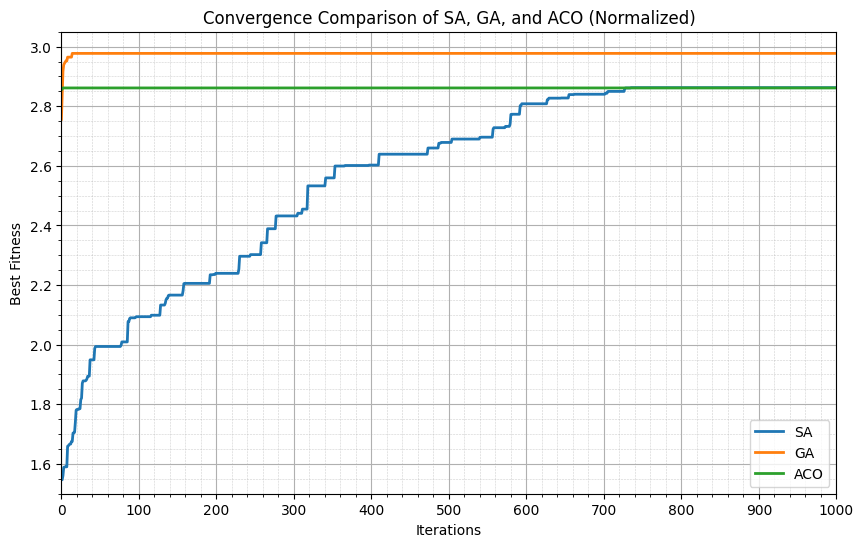

In [25]:
#Plots
from matplotlib.ticker import MultipleLocator

MAX_PLOT_ITERS = 1000

def normalize_curve(curve, max_len=MAX_PLOT_ITERS):

    curve = list(curve)

    if len(curve) == 0:
        return [0] * max_len

    if len(curve) > max_len:
        return curve[:max_len]

    return curve + [curve[-1]] * (max_len - len(curve))

sa_norm = normalize_curve(sa_avg)
ga_norm = normalize_curve(ga_avg)
aco_norm = normalize_curve(aco_avg)

plt.figure(figsize=(10, 6))

plt.plot(range(MAX_PLOT_ITERS), sa_norm, label="SA", linewidth=2)
plt.plot(range(MAX_PLOT_ITERS), ga_norm, label="GA", linewidth=2)
plt.plot(range(MAX_PLOT_ITERS), aco_norm, label="ACO", linewidth=2)

plt.xlim(0, MAX_PLOT_ITERS)
plt.ylim(1.5, 3.05)

plt.xlabel("Iterations")
plt.ylabel("Best Fitness")
plt.title("Convergence Comparison of SA, GA, and ACO (Normalized)")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(100))
ax.xaxis.set_minor_locator(MultipleLocator(20))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.grid(which='major', linestyle='-', linewidth=0.8)
ax.grid(which='minor', linestyle='--', linewidth=0.4, alpha=0.6)

plt.show()

## Interpretation of Convergence Behavior

The convergence curves reveal clear differences in how the algorithms search and improve solutions over iterations.

**Genetic Algorithm (GA)**: Converges extremely fast, reaching near-optimal fitness within the first ~20–30 iterations. After that, the curve becomes flat, indicating that the global optimum is found early and maintained.

**Ant Colony Optimization (ACO)**: Also converges quickly, though slightly slower than GA. Reaches a good solution early but stabilizes at a slightly lower fitness than the global optimum in most runs. This suggests that ACO benefits from early guidance (pheromone + heuristic) but may settle in near-optimal regions.

**Simulated Annealing (SA)**: Shows gradual and continuous improvement over many iterations. Starts with lower fitness and steadily increases, reflecting strong exploration. Eventually approaches high-quality solutions but takes significantly longer to converge compared to GA and ACO.

These results align with earlier statistical findings, where GA showed superior consistency, SA showed variability, and ACO demonstrated intermediate performance.

## Adaptive Parameter Control Strategies

The previous experiments showed that each algorithm has a different weakness:

**SA** is fast but may converge prematurely.

**GA** is accurate but can lose diversity after convergence.

**ACO** may stabilize below the optimum because pheromone trails become too dominant.

Unlike sensitivity analysis, adaptive tuning dynamically adjusts parameters based on search behavior. The adaptive strategy does not fully switch between exploration and exploitation.  Instead, it maintains a balance:
1. A baseline level of exploration is always preserved (to avoid getting trapped into local minima).
2. During improvement, the algorithm gradually increases exploitation but does not eliminate exploration.
3. During stagnation, exploration is increased to escape local optima.

This prevents premature convergence while still allowing efficient refinement of good solutions.

In [26]:
def fixed_sa_run(seed=None):
#Fixed SA
    return simulated_annealing_run(
        initial_temperature=100,
        cooling_rate=0.95,
        min_temperature=1e-4,
        max_iterations=3000,
        patience=500,
        reheat=False,
        seed=seed
    )


def adaptive_sa_run(seed=None):
#Adaptive SA
    return simulated_annealing_run(
        initial_temperature=100,
        cooling_rate=0.95,
        min_temperature=1e-4,
        max_iterations=3000,
        patience=500,
        reheat=True,
        reheat_factor=1.5,
        seed=seed
    )


def adaptive_ga_run(
    population_size=50,
    generations=300,
    crossover_rate=0.85,
    initial_mutation=0.20,
    min_mutation=0.08,
    max_mutation=0.50,
    stagnation_window=20,
    improvement_window=10,
    elitism_count=2,
    tournament_size=3,
    seed=None
):

#Adaptive GA
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    start_time = time.time()

    population = initialize_population(population_size)

    best_solution = max(population, key=fitness)
    best_fitness = fitness(best_solution)

    mutation_rate = initial_mutation
    no_improvement = 0
    recent_improvements = 0

    best_history = []
    mutation_history = []

    for generation in range(generations):
        population = sorted(population, key=fitness, reverse=True)

        elites = [individual.copy() for individual in population[:elitism_count]]
        new_population = elites.copy()

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_size)
            parent2 = tournament_selection(population, tournament_size)

            if random.random() < crossover_rate:
                child = order_based_crossover(parent1, parent2)
            else:
                child = parent1.copy()

            child = mutate_itinerary(child, mutation_rate)
            child = repair_itinerary(child)

            new_population.append(child)

        population = new_population

        generation_best = max(population, key=fitness)
        generation_best_fitness = fitness(generation_best)

        if generation_best_fitness > best_fitness:
            best_solution = generation_best.copy()
            best_fitness = generation_best_fitness

            no_improvement = 0
            recent_improvements += 1

            if recent_improvements >= improvement_window:
                mutation_rate = max(min_mutation, mutation_rate * 0.95)
                recent_improvements = 0

        else:
            no_improvement += 1
            recent_improvements = 0

            if no_improvement >= stagnation_window:
                mutation_rate = min(max_mutation, mutation_rate * 1.15)
                no_improvement = 0

        best_history.append(best_fitness)
        mutation_history.append(mutation_rate)

    runtime = time.time() - start_time

    return {
        "Algorithm": "Adaptive GA",
        "Best Itinerary": best_solution,
        "Best Fitness": best_fitness,
        "Runtime": runtime,
        "Iterations": generations,
        "Best History": best_history,
        "Mutation History": mutation_history,
        "Final Mutation Rate": mutation_rate
    }


def adaptive_aco_run(
    num_ants=25,
    iterations=300,
    alpha=1.0,
    beta=2.0,
    initial_evaporation=0.30,
    min_evaporation=0.12,
    max_evaporation=0.70,
    stagnation_window=20,
    improvement_window=10,
    seed=None
):

    #Adaptive ACO

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    start_time = time.time()

    n = commute_matrix.shape[0]
    pheromone = np.ones((n, n), dtype=float)

    best_solution = []
    best_fitness = -1

    evaporation_rate = initial_evaporation
    no_improvement = 0
    recent_improvements = 0

    best_history = []
    evaporation_history = []

    for iteration in range(iterations):
        solutions = []
        iteration_improved = False

        for _ in range(num_ants):
            itinerary = construct_solution(pheromone, alpha, beta)
            itinerary = [int(x) for x in itinerary]

            current_fitness = fitness(itinerary)
            solutions.append((itinerary, current_fitness))

            if current_fitness > best_fitness:
                best_solution = itinerary.copy()
                best_fitness = current_fitness
                iteration_improved = True

        if iteration_improved:
            no_improvement = 0
            recent_improvements += 1

            if recent_improvements >= improvement_window:
                evaporation_rate = max(min_evaporation, evaporation_rate * 0.95)
                recent_improvements = 0

        else:
            no_improvement += 1
            recent_improvements = 0

            if no_improvement >= stagnation_window:
                evaporation_rate = min(max_evaporation, evaporation_rate * 1.15)
                no_improvement = 0

        pheromone = update_pheromone(
            pheromone,
            solutions,
            evaporation_rate
        )

        best_history.append(best_fitness)
        evaporation_history.append(evaporation_rate)

    runtime = time.time() - start_time

    return {
        "Algorithm": "Adaptive ACO",
        "Best Itinerary": [int(x) for x in best_solution],
        "Best Fitness": best_fitness,
        "Runtime": runtime,
        "Iterations": iterations,
        "Best History": best_history,
        "Evaporation History": evaporation_history,
        "Final Evaporation Rate": evaporation_rate
    }

In [27]:
#Comparison

ADAPT_RUNS = 5

adaptive_results = []

for run in range(ADAPT_RUNS):
    seed = GLOBAL_SEED + run

    fixed_sa = fixed_sa_run(seed=seed)
    adaptive_sa = adaptive_sa_run(seed=seed)

    fixed_ga = genetic_algorithm_run(
        population_size=50,
        generations=300,
        crossover_rate=0.85,
        mutation_rate=0.20,
        elitism_count=2,
        tournament_size=3,
        seed=seed
    )

    adaptive_ga = adaptive_ga_run(seed=seed)

    fixed_aco = aco_run(
        num_ants=25,
        iterations=300,
        alpha=1.0,
        beta=2.0,
        evaporation_rate=0.30,
        seed=seed
    )

    adaptive_aco = adaptive_aco_run(seed=seed)

    for method_name, result in [
        ("Fixed SA", fixed_sa),
        ("Adaptive SA", adaptive_sa),
        ("Fixed GA", fixed_ga),
        ("Adaptive GA", adaptive_ga),
        ("Fixed ACO", fixed_aco),
        ("Adaptive ACO", adaptive_aco)
    ]:
        adaptive_results.append({
            "Run": run + 1,
            "Method": method_name,
            "Fitness": result["Best Fitness"],
            "Runtime": result["Runtime"],
            "Iterations": result["Iterations"],
            "Best Itinerary": result["Best Itinerary"]
        })

adaptive_df = pd.DataFrame(adaptive_results)

display(adaptive_df)

,Run,Method,Fitness,Runtime,Iterations,Best Itinerary
0,1,Fixed SA,2.495050,0.153204,270,"[3, 7, 9, 2]"
1,1,Adaptive SA,2.495050,0.147064,270,"[3, 7, 9, 2]"
2,1,Fixed GA,2.977316,59.688139,300,"[5, 3, 7, 2]"
3,1,Adaptive GA,2.977316,55.264200,300,"[5, 3, 7, 2]"
4,1,Fixed ACO,2.750491,58.551587,300,"[5, 1, 3]"
5,1,Adaptive ACO,2.750491,56.960204,300,"[5, 1, 3]"
6,2,Fixed SA,2.456140,0.140039,270,"[3, 7, 1, 2]"
7,2,Adaptive SA,2.456140,0.144360,270,"[3, 7, 1, 2]"
8,2,Fixed GA,2.977316,55.866755,300,"[5, 3, 7, 2]"
9,2,Adaptive GA,2.977316,51.057166,300,"[5, 3, 7, 2]"


In [28]:
#Summary

adaptive_summary = adaptive_df.groupby("Method").agg(
    Min_Fitness=("Fitness", "min"),
    Avg_Fitness=("Fitness", "mean"),
    Median_Fitness=("Fitness", "median"),
    Std_Fitness=("Fitness", "std"),
    Best_Fitness=("Fitness", "max"),
    Avg_Runtime=("Runtime", "mean"),
    Avg_Iterations=("Iterations", "mean")
).reset_index()

display(adaptive_summary)

,Method,Min_Fitness,Avg_Fitness,Median_Fitness,Std_Fitness,Best_Fitness,Avg_Runtime,Avg_Iterations
0,Adaptive ACO,2.750491,2.848892,2.788845,0.118276,2.977316,57.774043,300.0
1,Adaptive GA,2.977316,2.977316,2.977316,0.000000,2.977316,52.613134,300.0
2,Adaptive SA,2.456140,2.557428,2.495050,0.162111,2.845850,0.147414,273.2
3,Fixed ACO,2.750491,2.848892,2.788845,0.118276,2.977316,58.874374,300.0
4,Fixed GA,2.977316,2.977316,2.977316,0.000000,2.977316,57.740408,300.0
5,Fixed SA,2.456140,2.557428,2.495050,0.162111,2.845850,0.147877,270.0


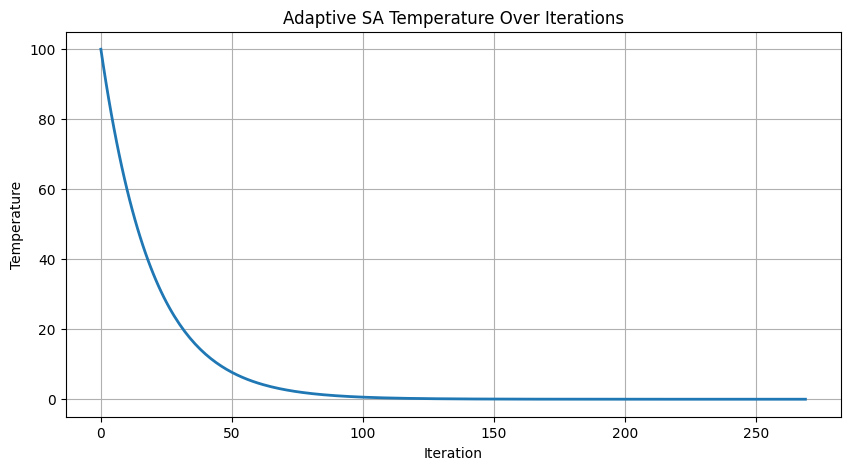

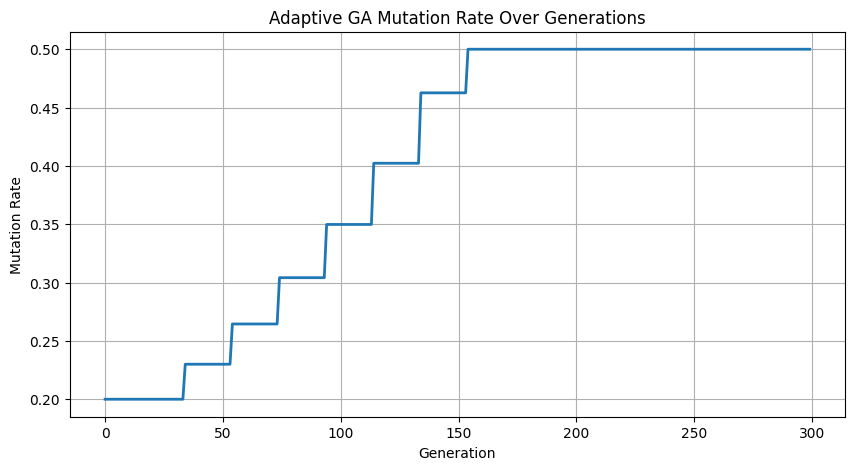

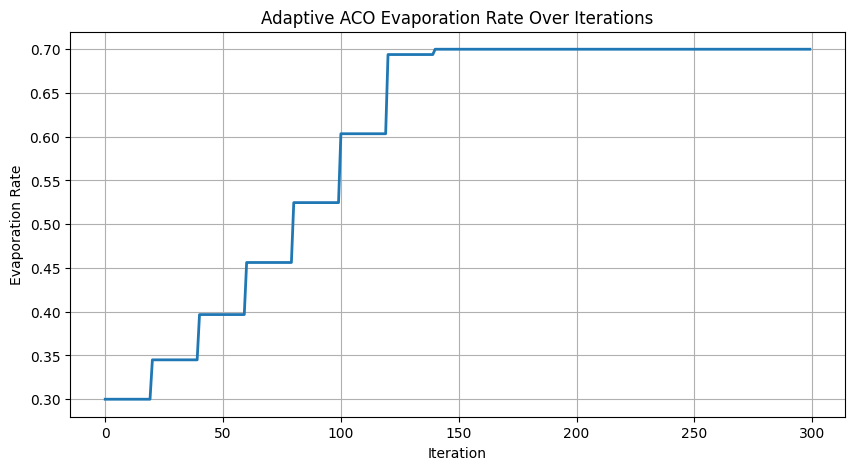

In [29]:
#Plot for parameter tracking

adaptive_sa_example = adaptive_sa_run(seed=GLOBAL_SEED)
adaptive_ga_example = adaptive_ga_run(seed=GLOBAL_SEED)
adaptive_aco_example = adaptive_aco_run(seed=GLOBAL_SEED)

plt.figure(figsize=(10, 5))
plt.plot(adaptive_sa_example["Temperature History"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Temperature")
plt.title("Adaptive SA Temperature Over Iterations")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(adaptive_ga_example["Mutation History"], linewidth=2)
plt.xlabel("Generation")
plt.ylabel("Mutation Rate")
plt.title("Adaptive GA Mutation Rate Over Generations")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(adaptive_aco_example["Evaporation History"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Evaporation Rate")
plt.title("Adaptive ACO Evaporation Rate Over Iterations")
plt.grid(True)
plt.show()

## Analysis of Adaptive Parameter Control

### Simulated Annealing (SA)

Fixed SA and Adaptive SA show **identical fitness values** across all runs: Average fitness ≈ 2.5574, Standard deviation ≈ 0.1621. Runtime is also nearly identical (~0.147 seconds), with only minor variation.

This indicates that: The adaptive reheating mechanism **did not significantly affect final solution quality**.
This is likely because:
  The problem size is small.
  The search space is relatively easy to explore.
  The stopping criteria (patience + temperature) already allow sufficient exploration.

From the temperature plot: The temperature decreases smoothly and reaches near zero quickly. No visible strong reheating effect is observed.

**Conclusion (SA):** Adaptive control does not significantly improve performance in this problem, but it does not degrade it either. Its benefits may become more evident in larger or more complex problems.

### Genetic Algorithm (GA)

Both Fixed GA and Adaptive GA consistently achieve the **global optimum (2.977316)** in all runs, with Standard deviation = 0 for both → perfectly stable. However, Adaptive GA shows **lower average runtime** (Fixed GA ≈ 57.74 seconds, Adaptive GA ≈ 52.61 seconds)

From the mutation rate plot: Mutation increases gradually during stagnation. It eventually stabilizes at a higher level (~0.5).

This suggests that the adaptive mechanism increases diversity when needed. However, since GA already finds the optimal solution easily, the benefit is mainly in **slightly improved efficiency**, not solution quality.

**Conclusion (GA):** Adaptive mutation improves computational efficiency slightly but does not improve solution quality, since the baseline GA already performs optimally.

### Ant Colony Optimization (ACO)

Fixed and Adaptive ACO show **identical fitness statistics**: Average fitness ≈ 2.8489, Standard deviation ≈ 0.1183. However, Adaptive ACO shows a **slight runtime improvement**: Fixed ACO ≈ 58.87 seconds, Adaptive ACO ≈ 57.77 seconds.

From the evaporation plot: Evaporation rate increases steadily during stagnation, reaching ~0.7. This indicates that the algorithm shifts toward exploration when improvement slows down. However: This increased exploration does not translate into better fitness. This is likely because the problem landscape is simple, hence the optimal region is already reachable with the fixed parameters.

**Conclusion (ACO):**
Adaptive evaporation modifies search behavior but does not significantly improve solution quality. It provides only marginal efficiency gains.

### Overall Interpretation

Across all algorithms, adaptive strategies **do not significantly improve fitness performance**. This is because the problem is relatively small and already solvable with fixed parameters. However, they do not harm performance either as slight improvement in runtime have been found.

The adaptive strategies successfully maintain a balance between exploration and exploitation without introducing instability.

## Final Conclusion

This study presented a comparative analysis of three heuristic algorithms—Simulated Annealing (SA), Genetic Algorithm (GA), and Ant Colony Optimization (ACO)—for solving the trip itinerary planning problem.

### Overall Performance

**Genetic Algorithm (GA)** consistently achieved the global optimal solution in all runs. It is the most reliable and stable algorithm. However, it has the highest computational cost.

**Simulated Annealing (SA)** demonstrated the fastest runtime. It is highly efficient but less stable. It occasionally converges to suboptimal solutions.

**Ant Colony Optimization (ACO)** provided balanced performance. It performs better than SA in average fitness. However, it is slower and less consistent than GA.

### Statistical Validation

Statistical tests (Wilcoxon Rank-Sum and Friedman Test) confirmed that:

1. GA significantly outperforms both SA and ACO in terms of solution quality.
2. SA and ACO show comparable performance, with no statistically significant difference.

These results validate that GA is the most effective method for this problem.


### Convergence Behavior

1. GA converges rapidly to the optimal solution and remains stable.
2. SA shows gradual improvement and strong exploration capability.
3. ACO converges steadily but may stabilize below the optimum.

### Effect of Adaptive Parameter Control

Adaptive parameter control strategies were introduced to improve algorithm robustness. Results show that adaptive tuning **does not significantly improve solution quality** for this problem. However, it does slightly reduces runtime (GA and ACO) and maintains stable performance.

This suggests that adaptive strategies are **more valuable for complex or large-scale problems**, where parameter sensitivity is higher.

This work demonstrates that while heuristic algorithms can effectively solve itinerary optimization problems, their relative performance depends on the trade-off between solution quality, computational cost, and robustness.